In [33]:
import pandas as pd

data = pd.read_csv("data/U4_01_housing.csv")

In [34]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='latitude', ylabel='longitude'>

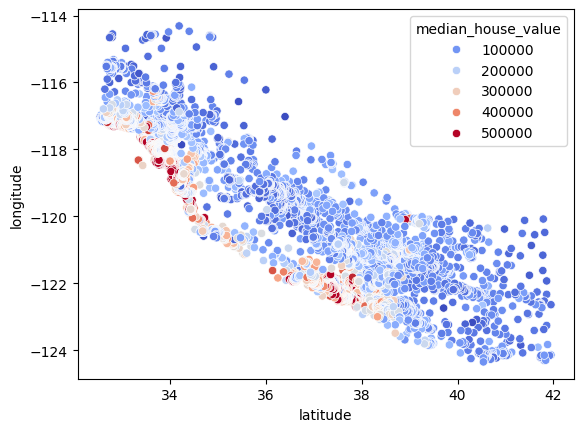

In [35]:
import seaborn as sb 
sb.scatterplot(x="latitude", y="longitude", data=data, hue="median_house_value", palette="coolwarm")

<Axes: xlabel='latitude', ylabel='longitude'>

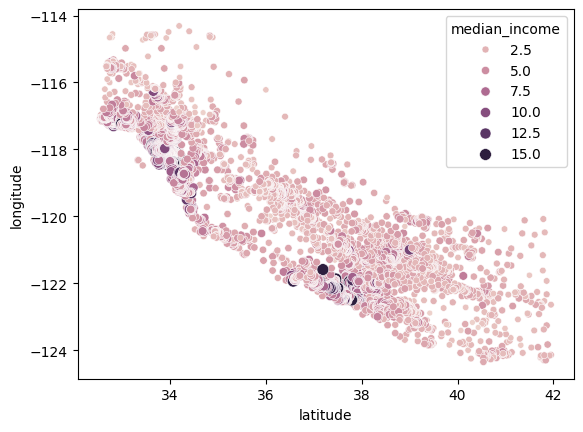

In [36]:
import seaborn as sb 
sb.scatterplot(x="latitude", y="longitude", data=data, hue="median_income", size=data["median_income"])

In [37]:
data.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


In [38]:
from sklearn.cluster import KMeans

X = data.loc[:, ["latitude", "longitude", "median_income"]]
model = KMeans(n_clusters=6)
prediksi = model.fit_predict(X)

In [39]:
prediksi.shape

(20640,)

In [40]:
X["economic_cluster"] = prediksi

In [41]:
X

,latitude,longitude,median_income,economic_cluster
0,37.88,-122.23,8.3252,5
1,37.86,-122.22,8.3014,5
2,37.85,-122.24,7.2574,5
3,37.85,-122.25,5.6431,5
4,37.85,-122.25,3.8462,1
...,...,...,...,...
20635,39.48,-121.09,1.5603,1
20636,39.49,-121.21,2.5568,1
20637,39.43,-121.22,1.7000,1
20638,39.43,-121.32,1.8672,1


In [42]:
X["economic_cluster"].value_counts()

economic_cluster
2    6939
1    4876
0    3911
5    2770
3    1682
4     462
Name: count, dtype: int64

<Axes: xlabel='latitude', ylabel='longitude'>

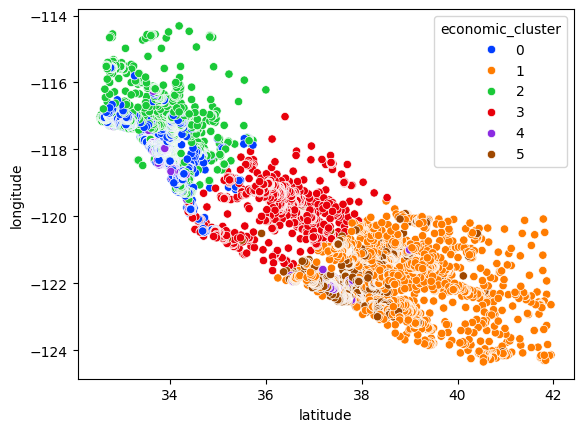

In [43]:
import seaborn as sb 
sb.scatterplot(x="latitude", y="longitude", data=X, hue="economic_cluster", palette="bright")

<Axes: xlabel='economic_cluster', ylabel='count'>

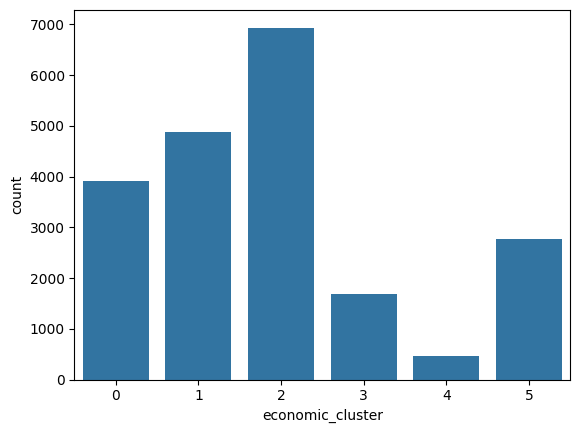

In [44]:
sb.countplot(x="economic_cluster", data=X)

In [45]:
X.groupby(["economic_cluster"])["median_income"].mean()

economic_cluster
0     5.487869
1     2.822577
2     2.859692
3     2.665690
4    10.929213
5     5.519249
Name: median_income, dtype: float64